In [1]:
%pip install -e ..

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Obtaining file:///home/f73aeabd-6de4-471d-92a9-1ba552ae6153/DeutschJozsaNoise
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for deutsch-jozsa-noise (pyproject.toml) ... done
  Created wheel for deutsch-jozsa-noise: filename=deutsch_jozsa_noise-0.0.1-0.editable-py3-none-any.whl size=3618 sha256=5c05518dcf13842e20fbbe4a916a04d7d58aab9b0d6f7723db41daba0bd03c24
  Stored in directory: /tmp/pip-ephem-wheel-cache-7b_50pm8/wheels/cd/70/c5/4f3c38fe54c84d43722d7ec83f18ffbc1a522022965cfe2165
Successfully built deutsch-jozsa-noise
  Attempting uninstall: deutsch-jozsa-noise
    Found existing installation: deutsch-jozsa-noise 0.0.1
    Uninstalling deutsch-jozsa-noise-0.0.1:
      Successfully uninstall

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import quantum_algorithms as qa

In [3]:
# Experiment settings

shots = 1024
n_values = [1, 3, 5, 7, 9]
theta_values = np.radians(np.arange(0, 181, 10))

functions = {
    "constant_0": qa.deutsch_jozsa.f_constant_0,
    "constant_1": qa.deutsch_jozsa.f_constant_1,
    "balanced": qa.deutsch_jozsa.f_balanced_parity,
}

axes = {
    "X": (1, 0, 0),
    "Y": (0, 1, 0),
    "Z": (0, 0, 1),
}

error_positions = {
    "E1_before_H": qa.deutsch_jozsa.deutsch_jozsa_error1,
    "E2_after_first_H": qa.deutsch_jozsa.deutsch_jozsa_error2,
    "E3_after_oracle": qa.deutsch_jozsa.deutsch_jozsa_error3,
    "E4_after_final_H": qa.deutsch_jozsa.deutsch_jozsa_error4,
}

In [4]:
# simulation with shots

start_time = time.time()
rng = np.random.default_rng(12345)
results = []

for n in n_values:
    print(f"Running n = {n}")

    for theta in theta_values:
        theta_deg = np.degrees(theta)

        for axis_name, axis in axes.items():
            for target_qubit in range(n):

                for function_name, f in functions.items():

                    state_ideal = qa.deutsch_jozsa.deutsch_jozsa(n, f)

                    samples_ideal = qa.deutsch_jozsa.sample_measurements_input(
                        state_ideal, n, shots, rng
                    )

                    P0_ideal = samples_ideal[0] / shots

                    if function_name.startswith("constant"):
                        success_ideal = P0_ideal
                    else:
                        success_ideal = 1 - P0_ideal

                    results.append({
                        "n": n,
                        "theta_rad": theta,
                        "theta_deg": theta_deg,
                        "axis": axis_name,
                        "target_qubit": target_qubit,
                        "function": function_name,
                        "error_position": "no_error",
                        "P0": P0_ideal,
                        "success": success_ideal,
                        "shots": shots,
                    })

                    for error_name, error_function in error_positions.items():

                        state_error = error_function(
                            n=n,
                            f=f,
                            theta=theta,
                            target_qubit=target_qubit,
                            axis=axis,
                        )

                        samples_error = qa.deutsch_jozsa.sample_measurements_input(
                            state_error, n, shots, rng
                        )

                        P0_error = samples_error[0] / shots

                        if function_name.startswith("constant"):
                            success_error = P0_error
                        else:
                            success_error = 1 - P0_error

                        results.append({
                            "n": n,
                            "theta_rad": theta,
                            "theta_deg": theta_deg,
                            "axis": axis_name,
                            "target_qubit": target_qubit,
                            "function": function_name,
                            "error_position": error_name,
                            "P0": P0_error,
                            "success": success_error,
                            "shots": shots,
                        })

end_time = time.time()

df = pd.DataFrame(results)

Running n = 1
Running n = 3
Running n = 5
Running n = 7
Running n = 9


In [5]:
df.to_csv("rotation_error_scalability_results_shots_1024.csv", index=False)

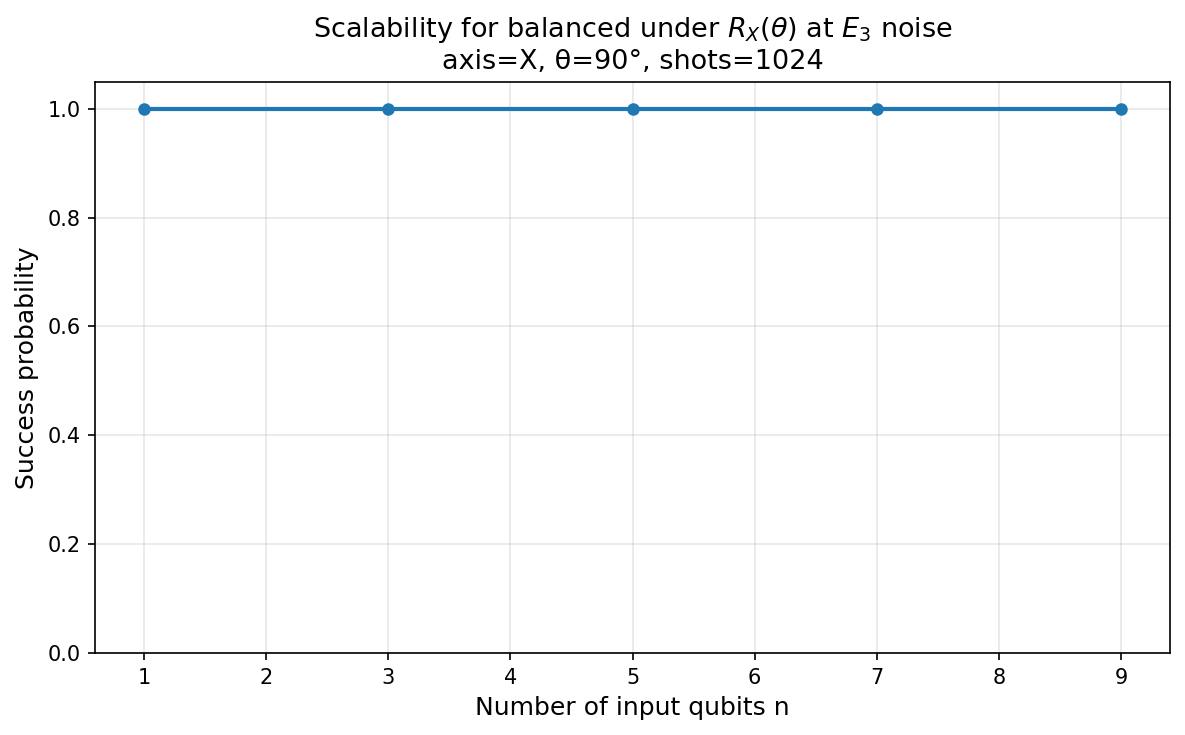

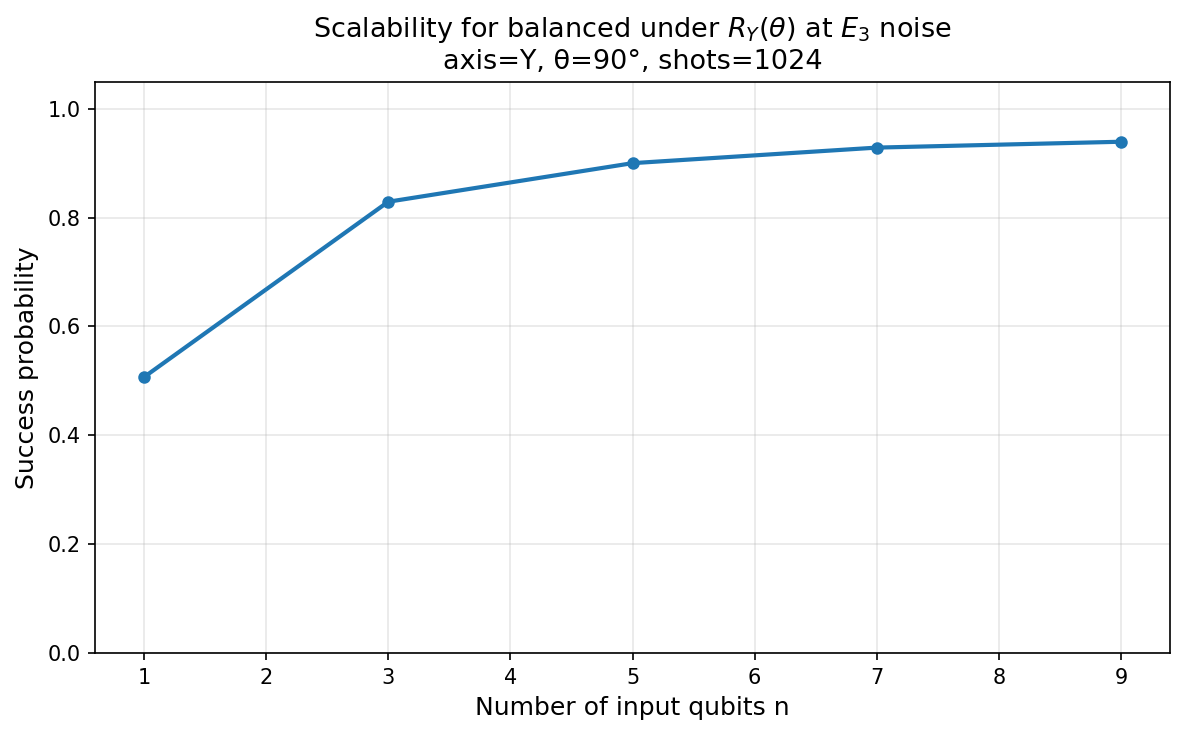

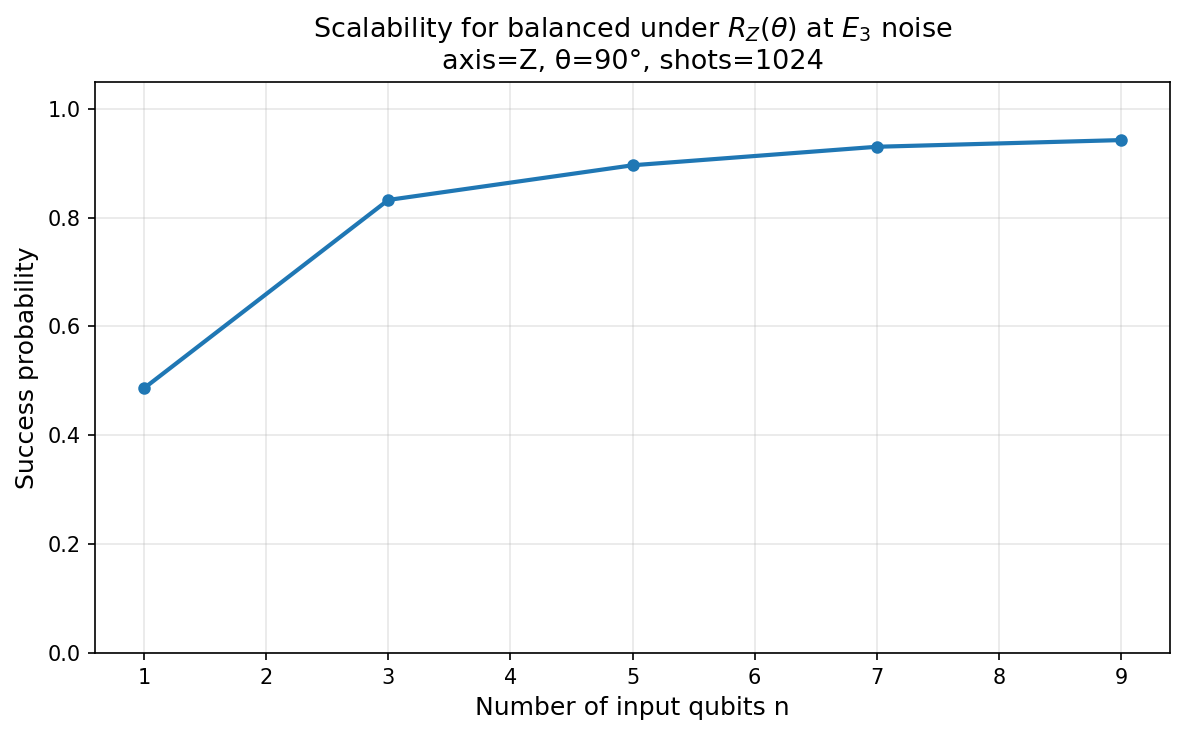

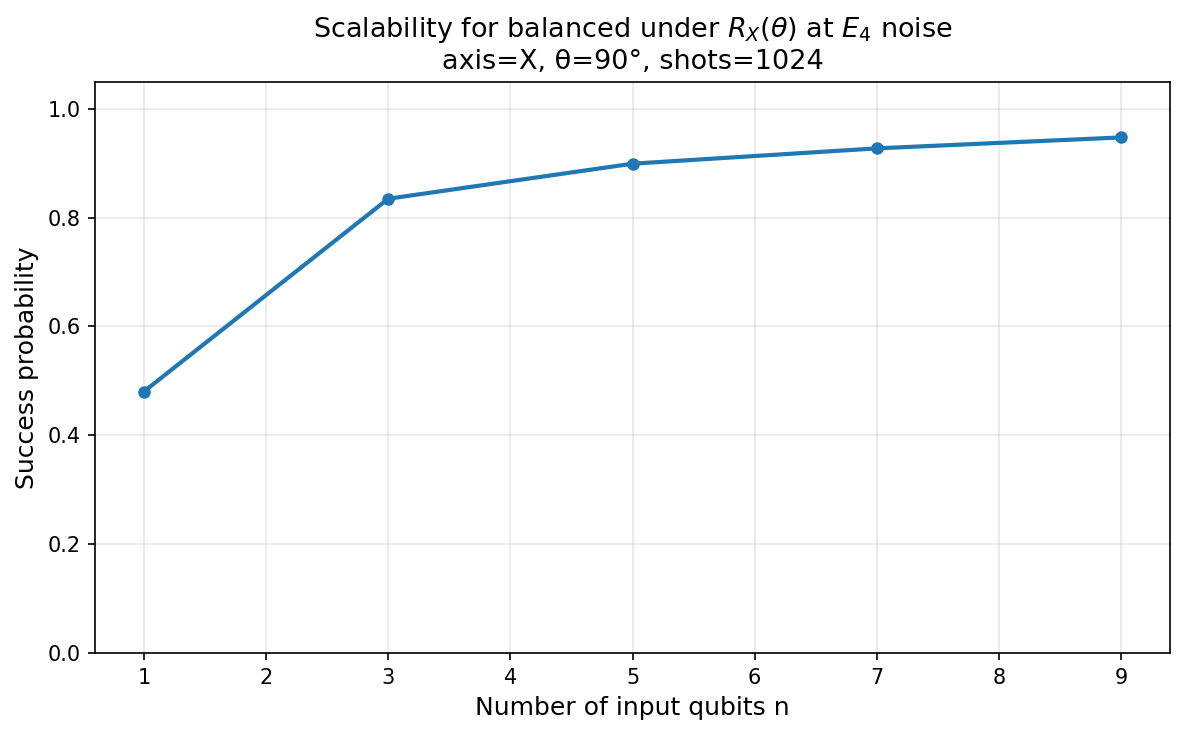

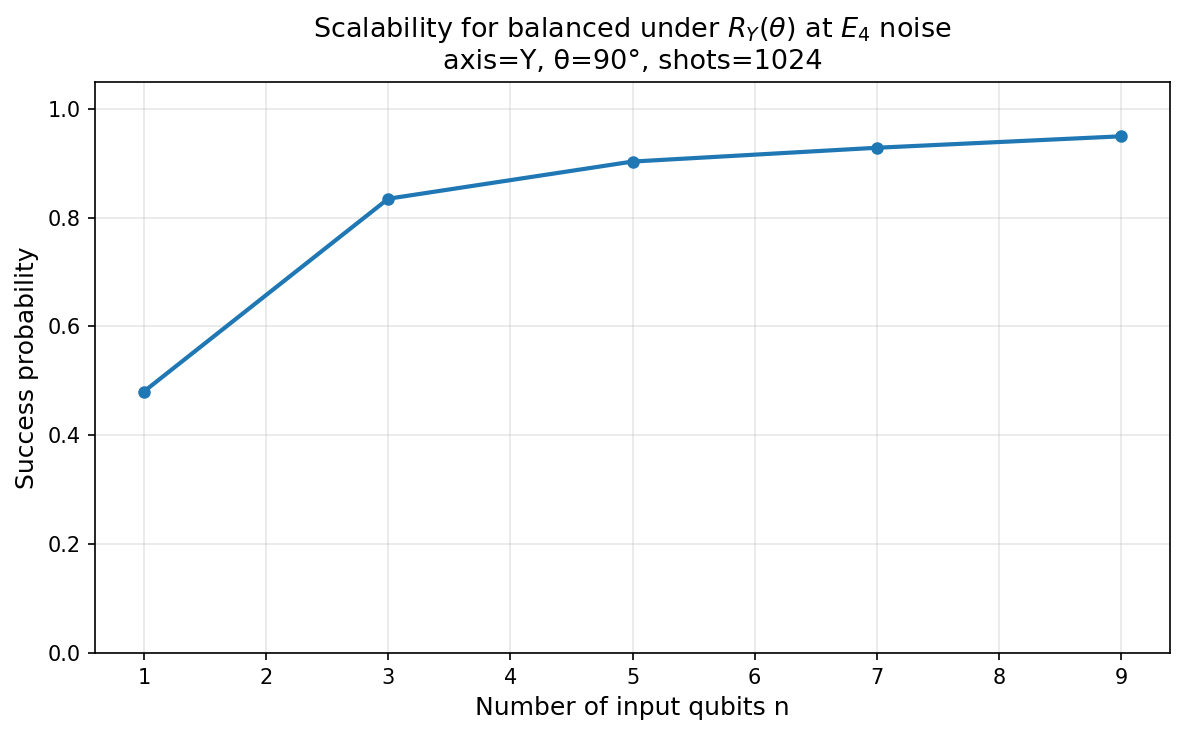

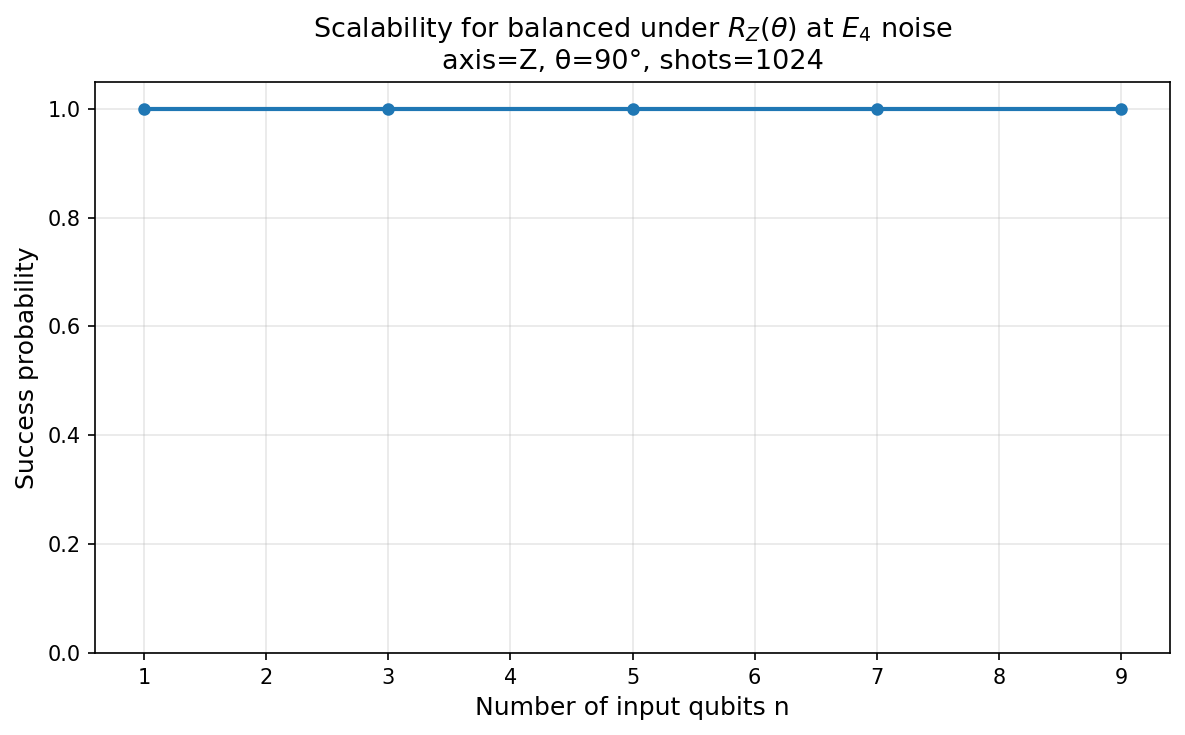

In [6]:
# E3
qa.plotting.rotation_error_scalability(df, 90, "X", "E3_after_oracle", "balanced", 1024)
qa.plotting.rotation_error_scalability(df, 90, "Y", "E3_after_oracle", "balanced", 1024)
qa.plotting.rotation_error_scalability(df, 90, "Z", "E3_after_oracle", "balanced", 1024)

# E4
qa.plotting.rotation_error_scalability(df, 90, "X", "E4_after_final_H", "balanced", 1024)
qa.plotting.rotation_error_scalability(df, 90, "Y", "E4_after_final_H", "balanced", 1024)
qa.plotting.rotation_error_scalability(df, 90, "Z", "E4_after_final_H", "balanced", 1024)

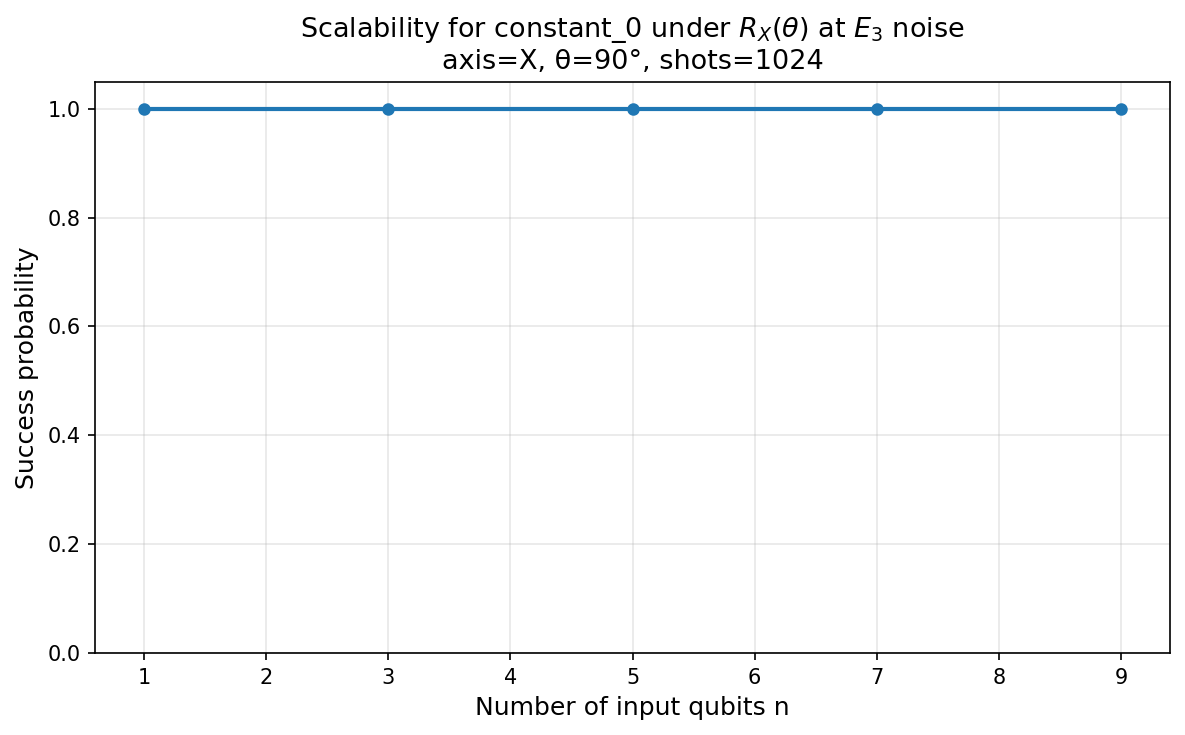

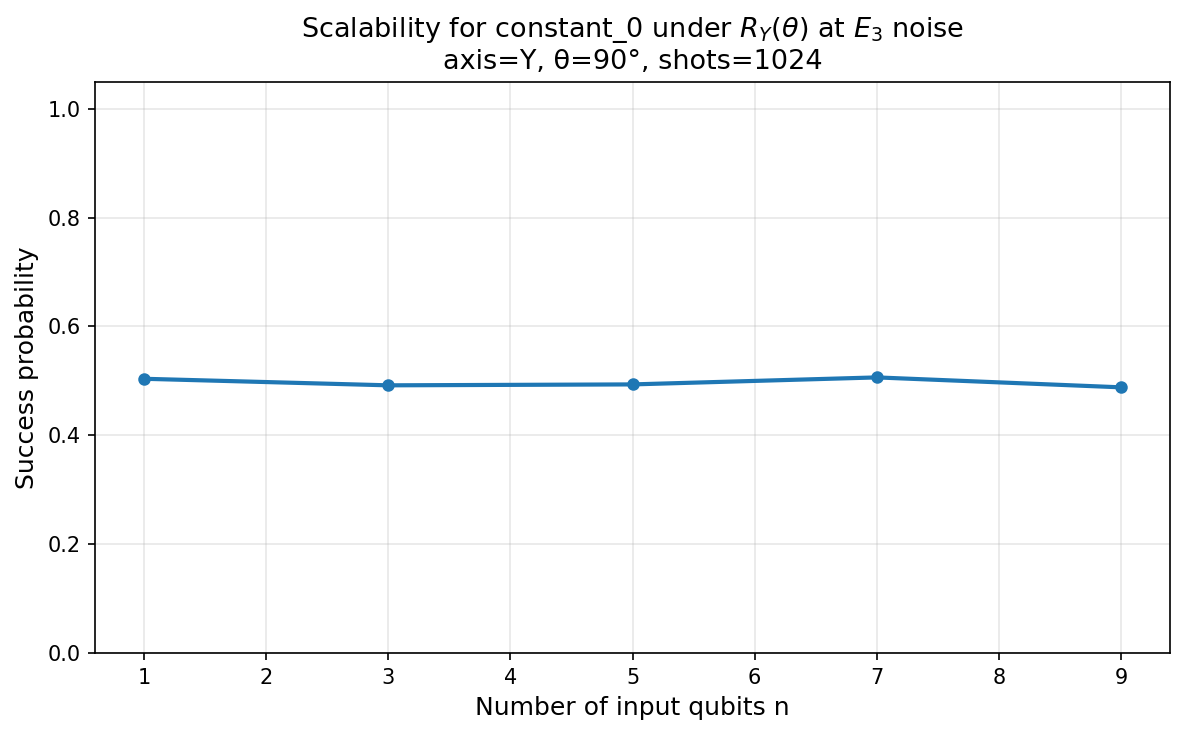

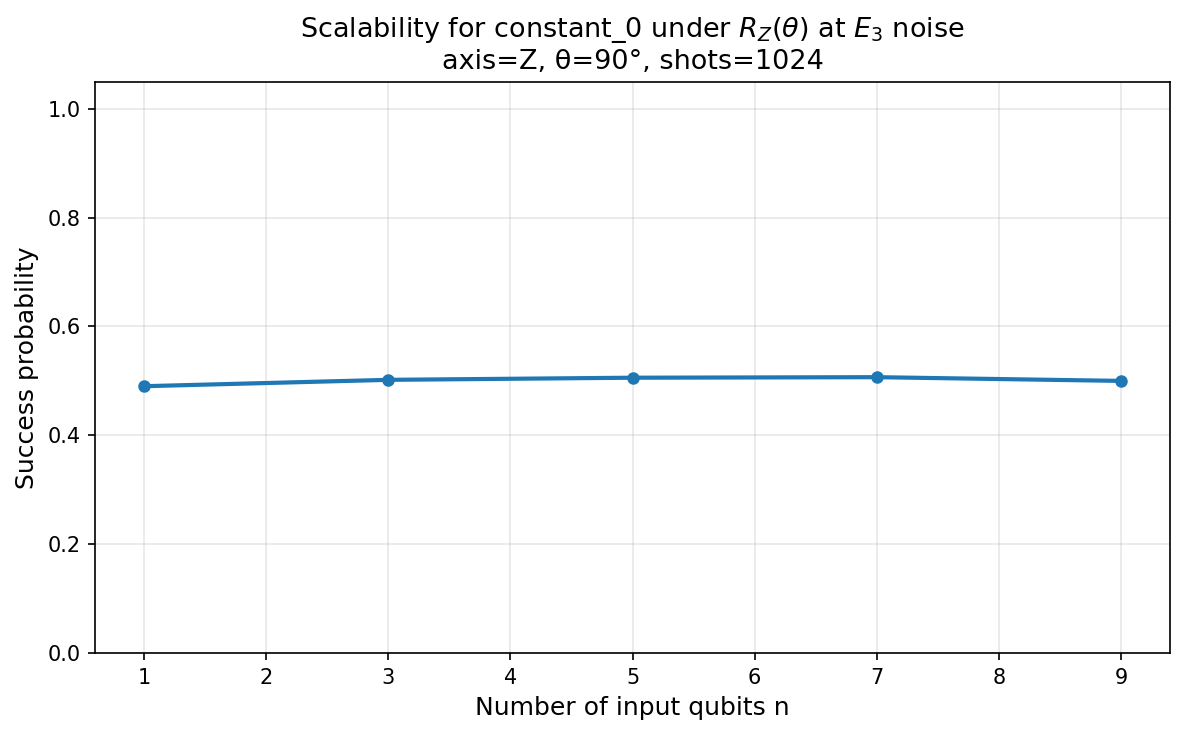

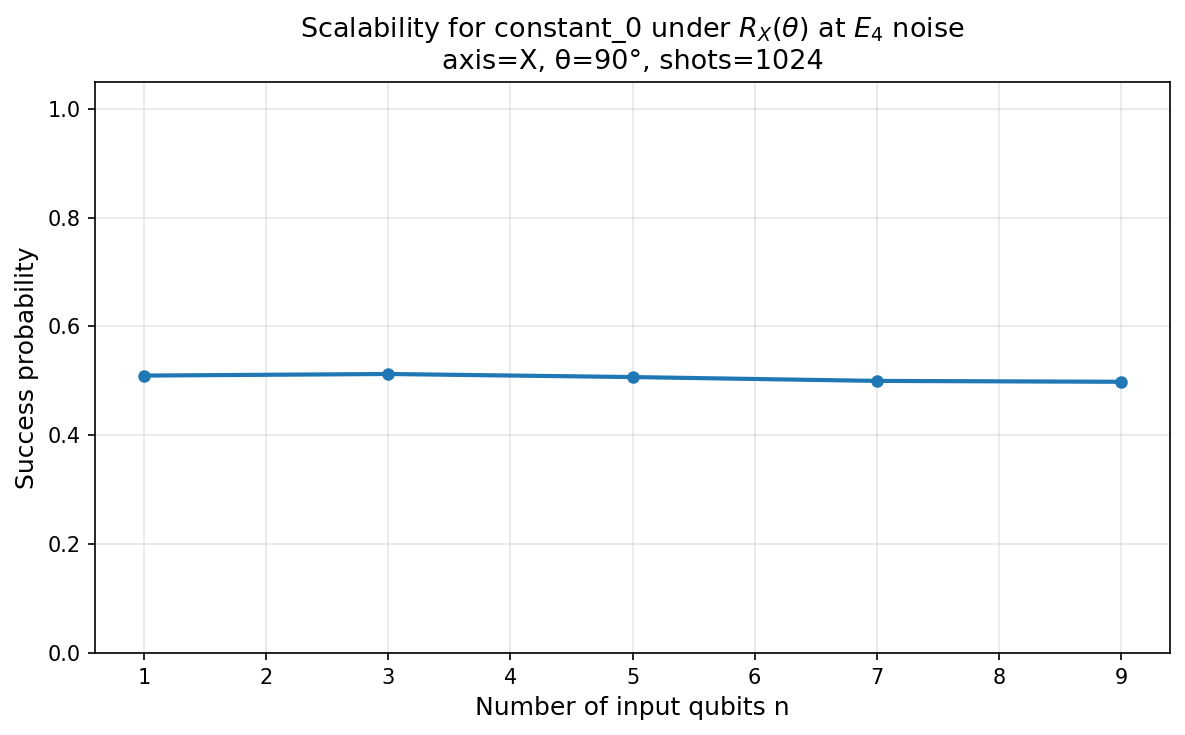

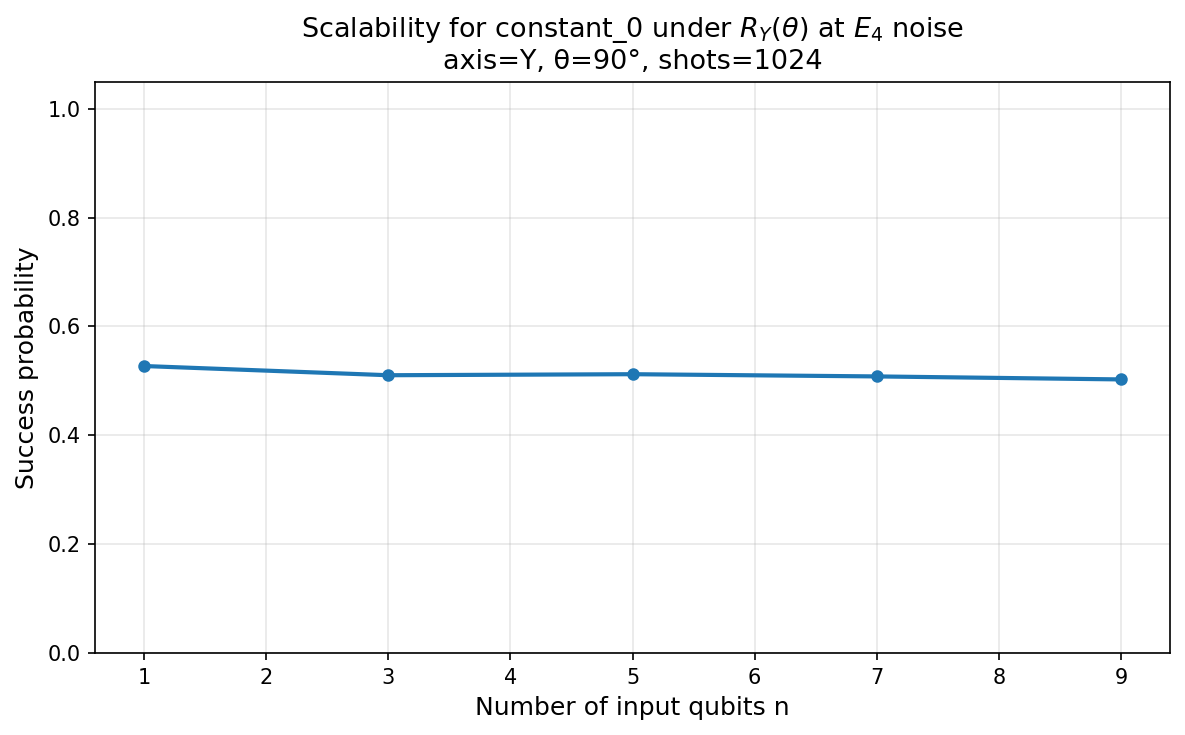

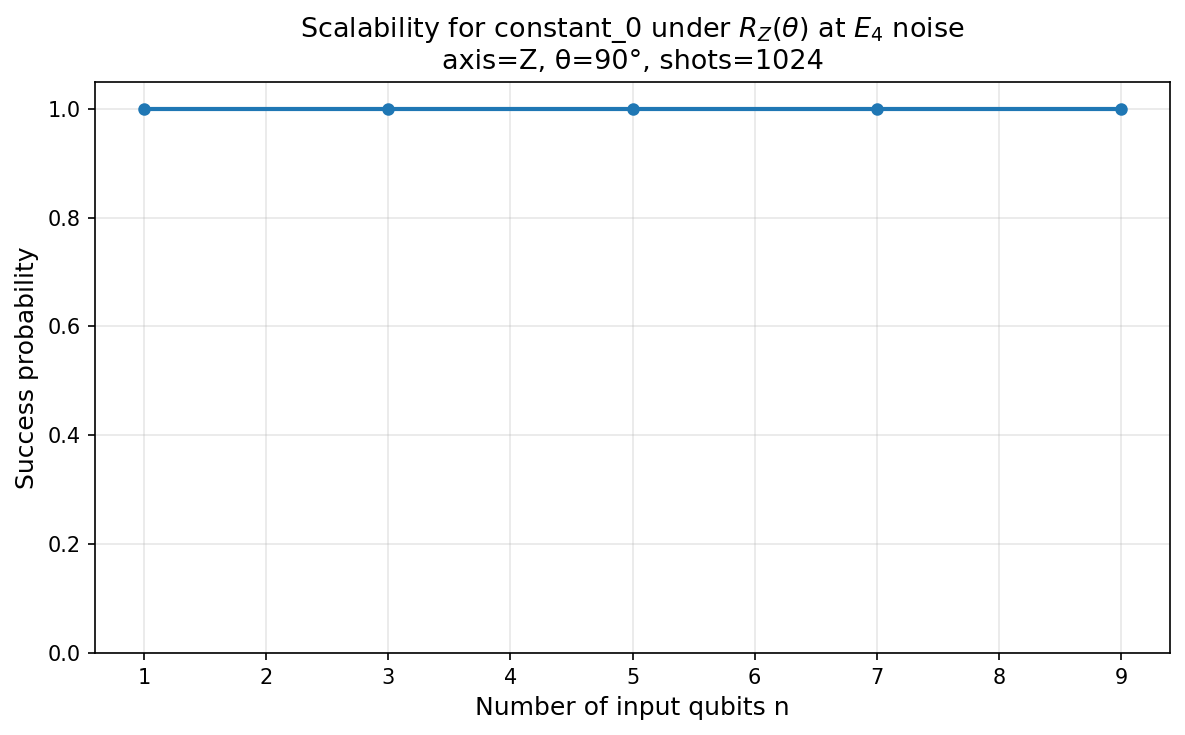

In [7]:
# E3
qa.plotting.rotation_error_scalability(df, 90, "X", "E3_after_oracle", "constant_0", 1024)
qa.plotting.rotation_error_scalability(df, 90, "Y", "E3_after_oracle", "constant_0", 1024)
qa.plotting.rotation_error_scalability(df, 90, "Z", "E3_after_oracle", "constant_0", 1024)

# E4
qa.plotting.rotation_error_scalability(df, 90, "X", "E4_after_final_H", "constant_0", 1024)
qa.plotting.rotation_error_scalability(df, 90, "Y", "E4_after_final_H", "constant_0", 1024)
qa.plotting.rotation_error_scalability(df, 90, "Z", "E4_after_final_H", "constant_0", 1024)

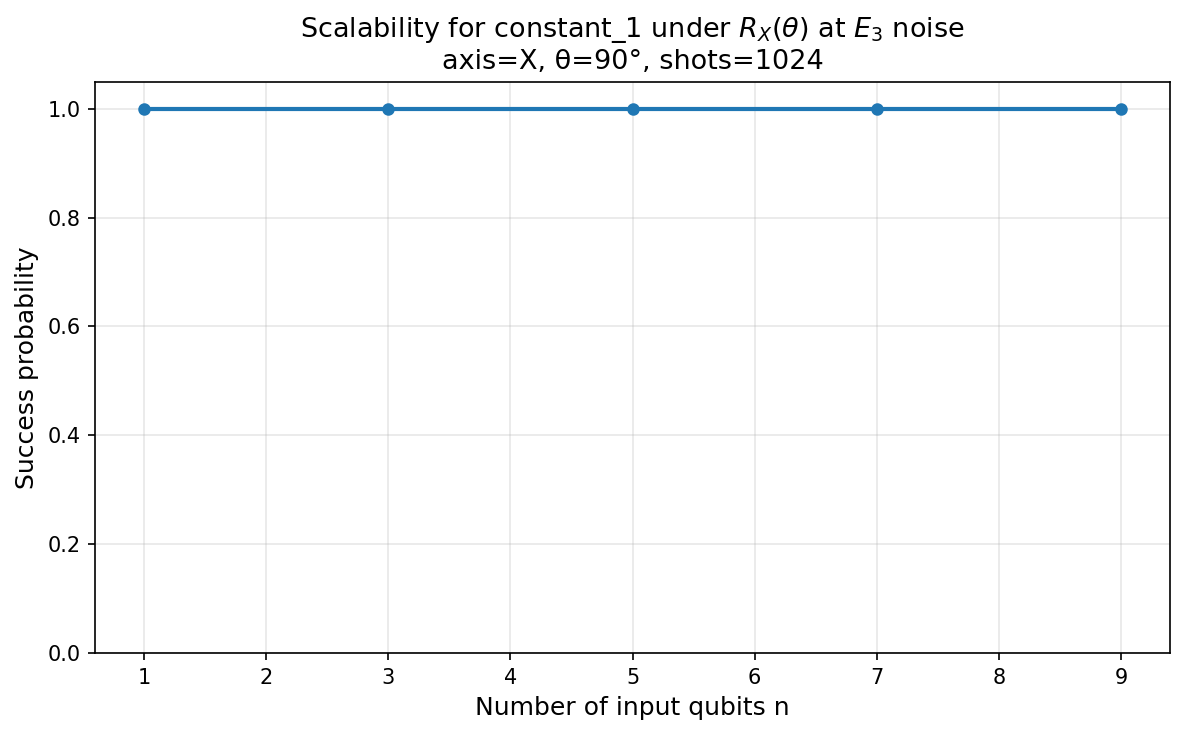

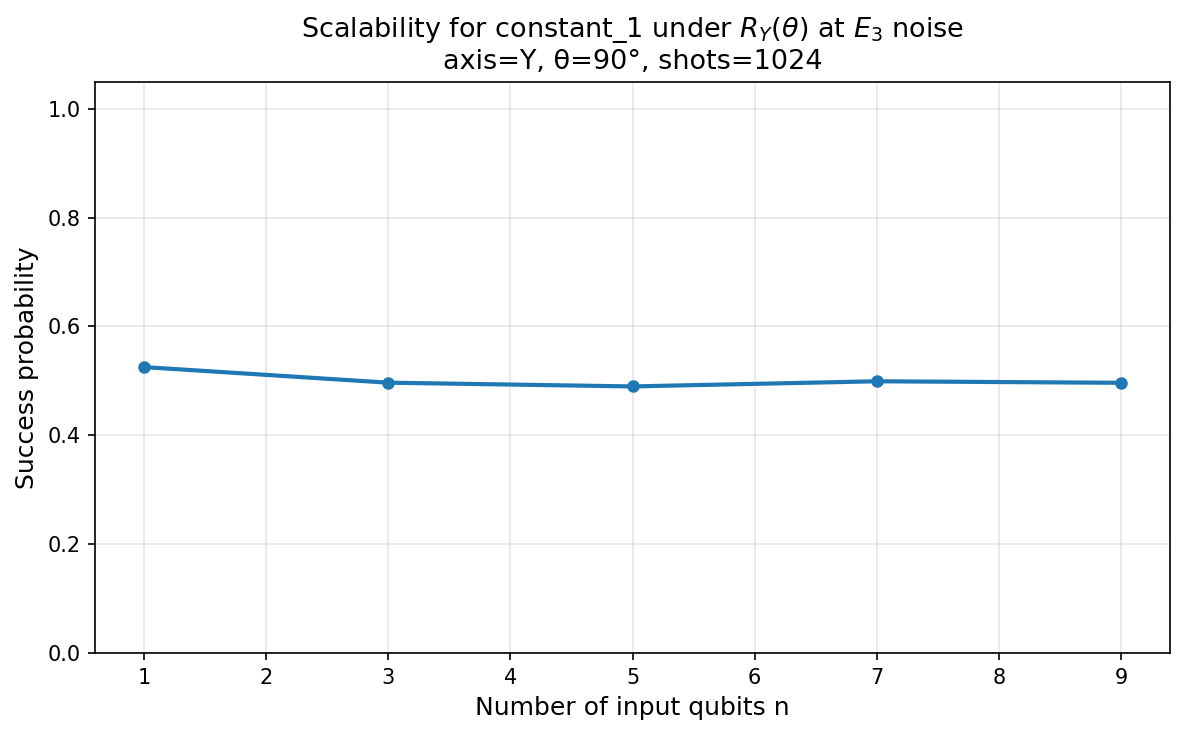

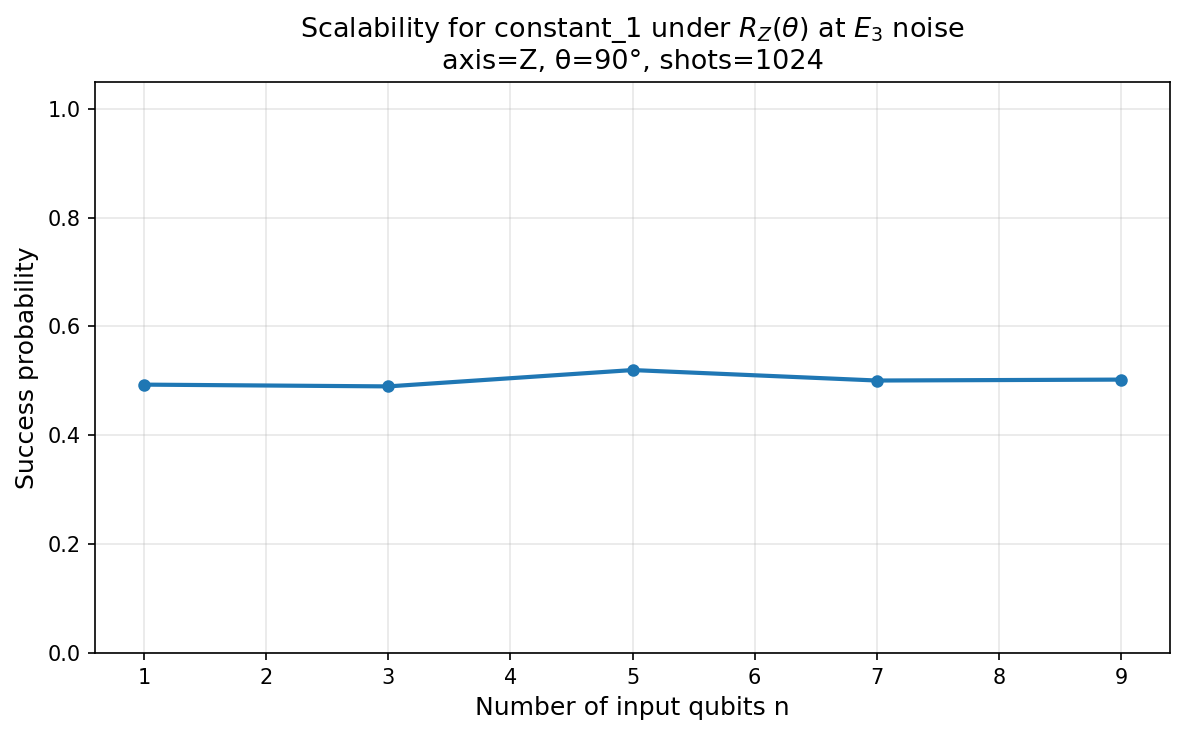

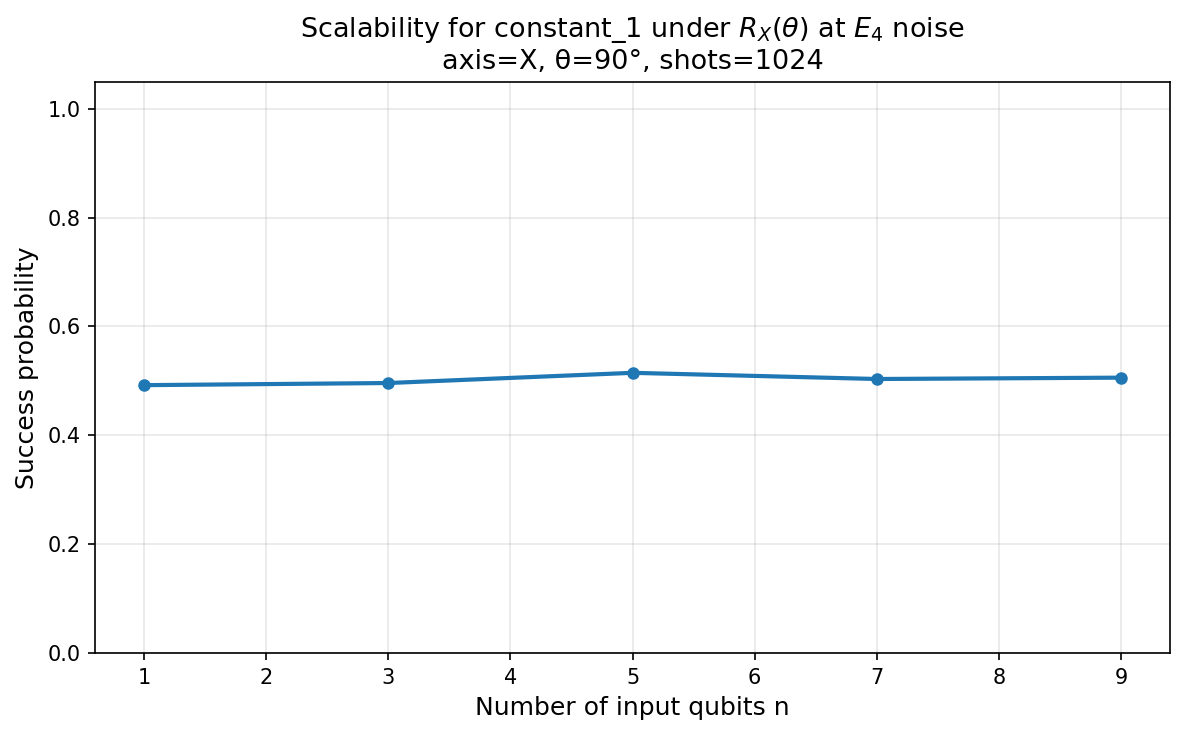

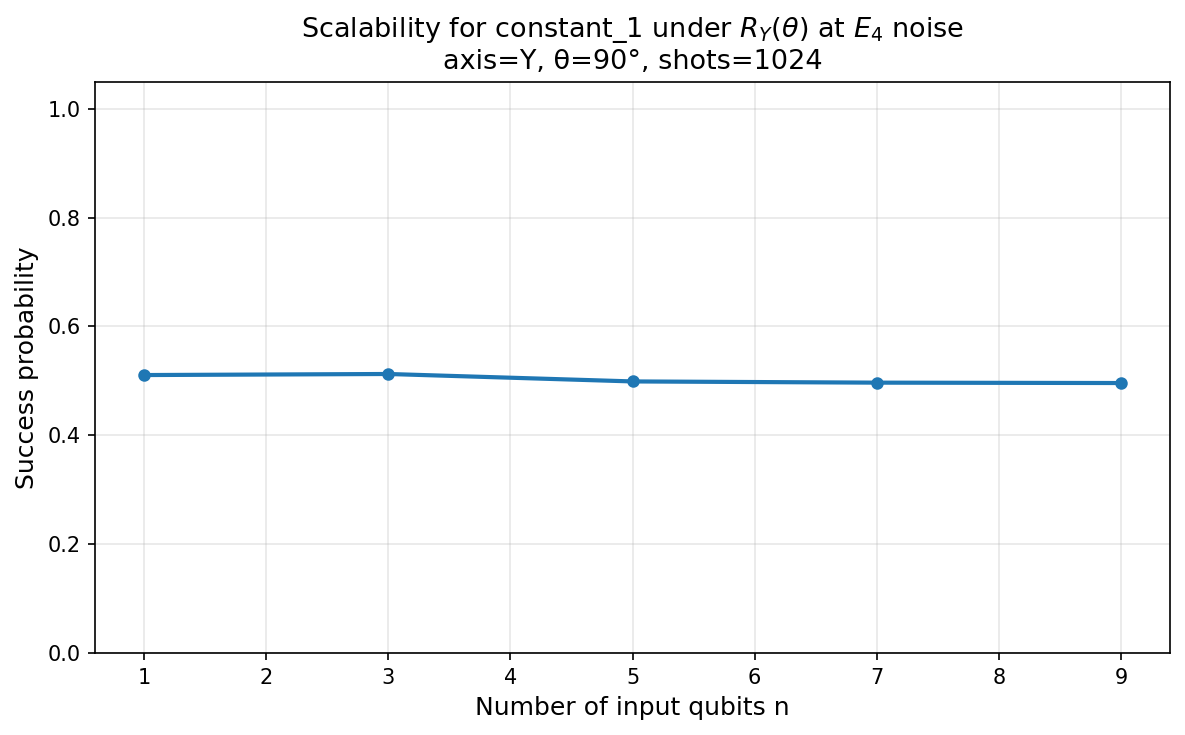

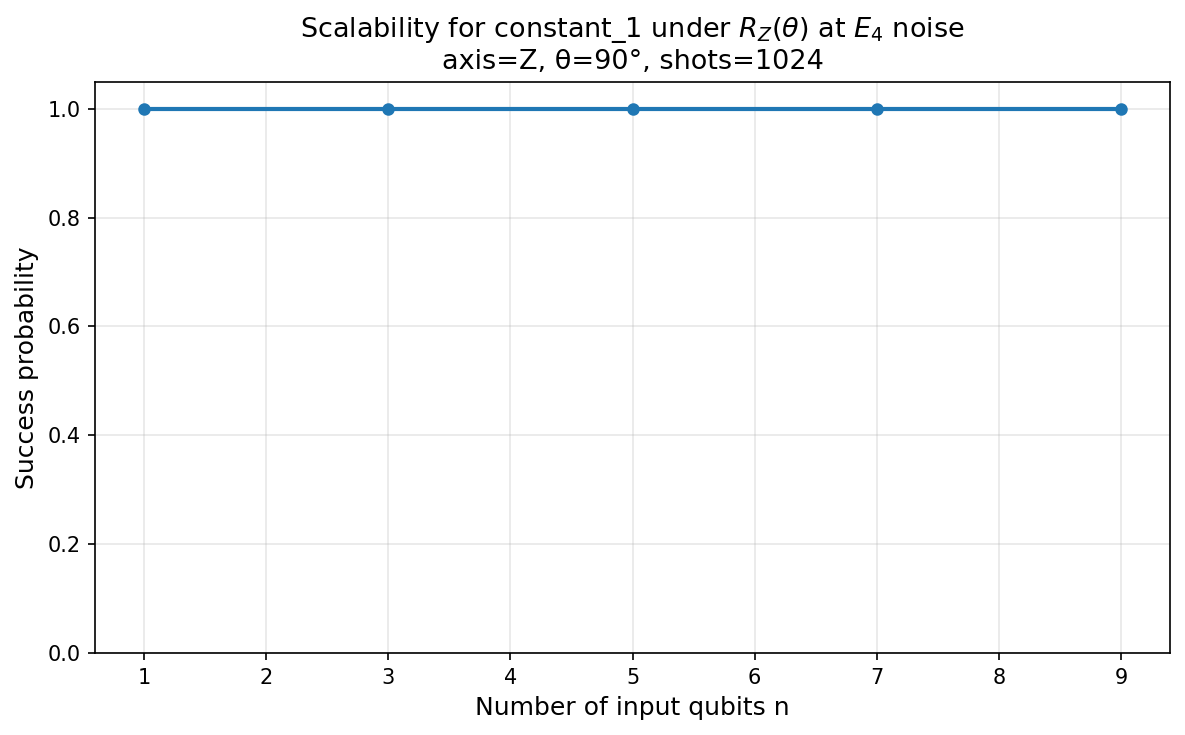

In [8]:
# E3
qa.plotting.rotation_error_scalability(df, 90, "X", "E3_after_oracle", "constant_1", 1024)
qa.plotting.rotation_error_scalability(df, 90, "Y", "E3_after_oracle", "constant_1", 1024)
qa.plotting.rotation_error_scalability(df, 90, "Z", "E3_after_oracle", "constant_1", 1024)

# E4
qa.plotting.rotation_error_scalability(df, 90, "X", "E4_after_final_H", "constant_1", 1024)
qa.plotting.rotation_error_scalability(df, 90, "Y", "E4_after_final_H", "constant_1", 1024)
qa.plotting.rotation_error_scalability(df, 90, "Z", "E4_after_final_H", "constant_1", 1024)

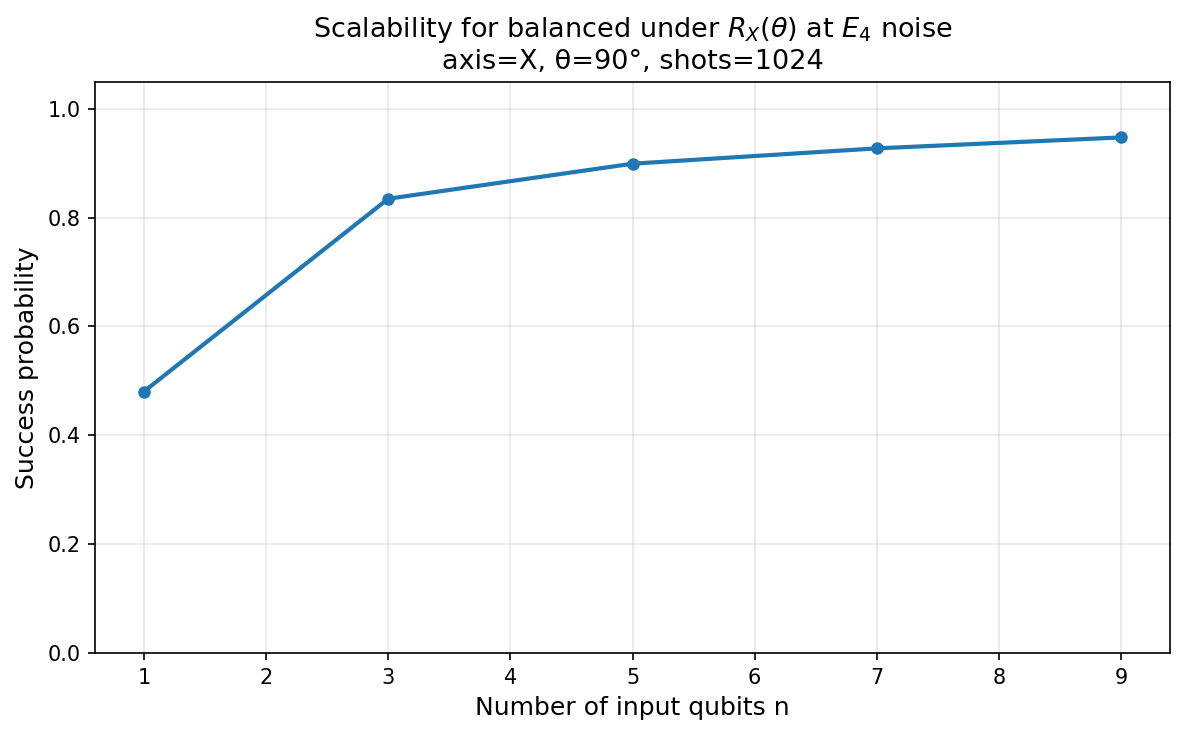

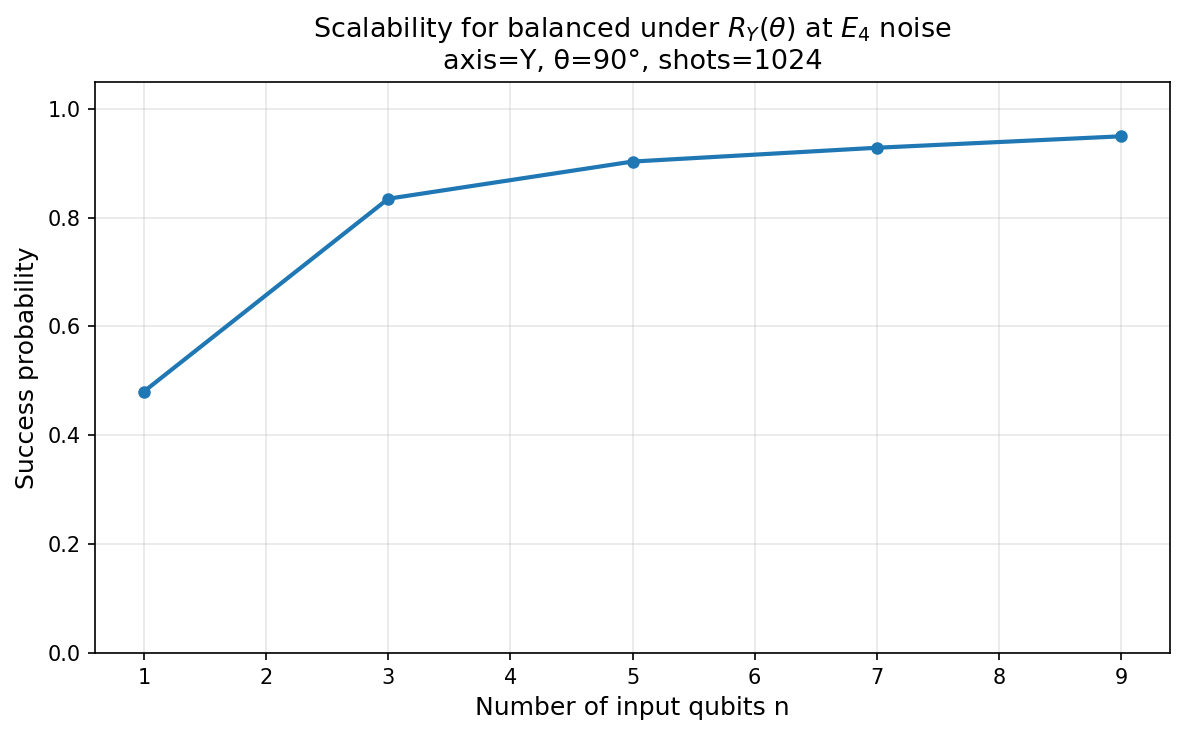

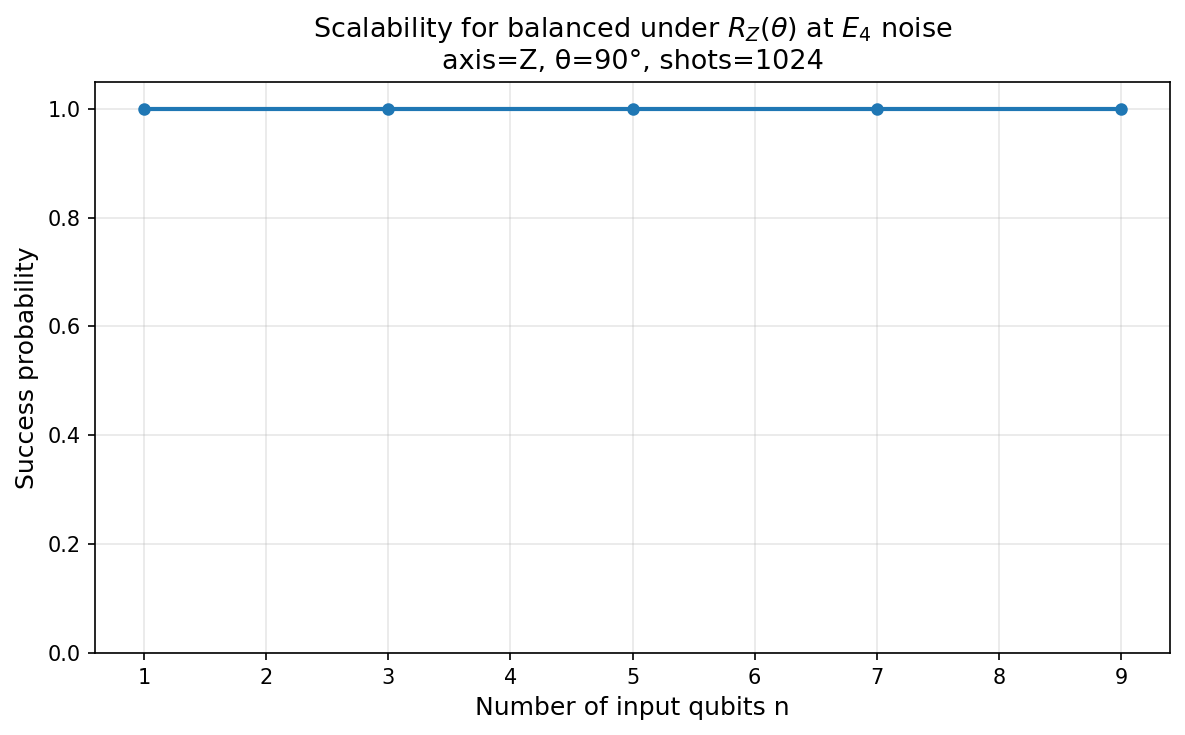

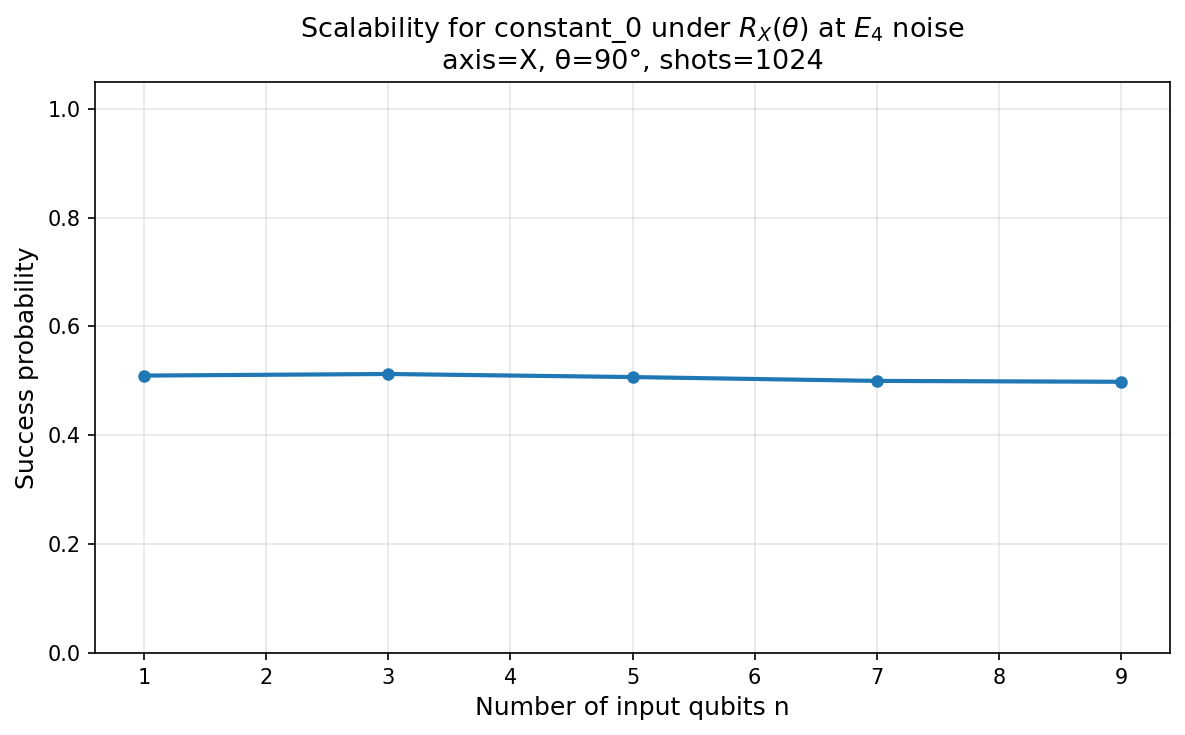

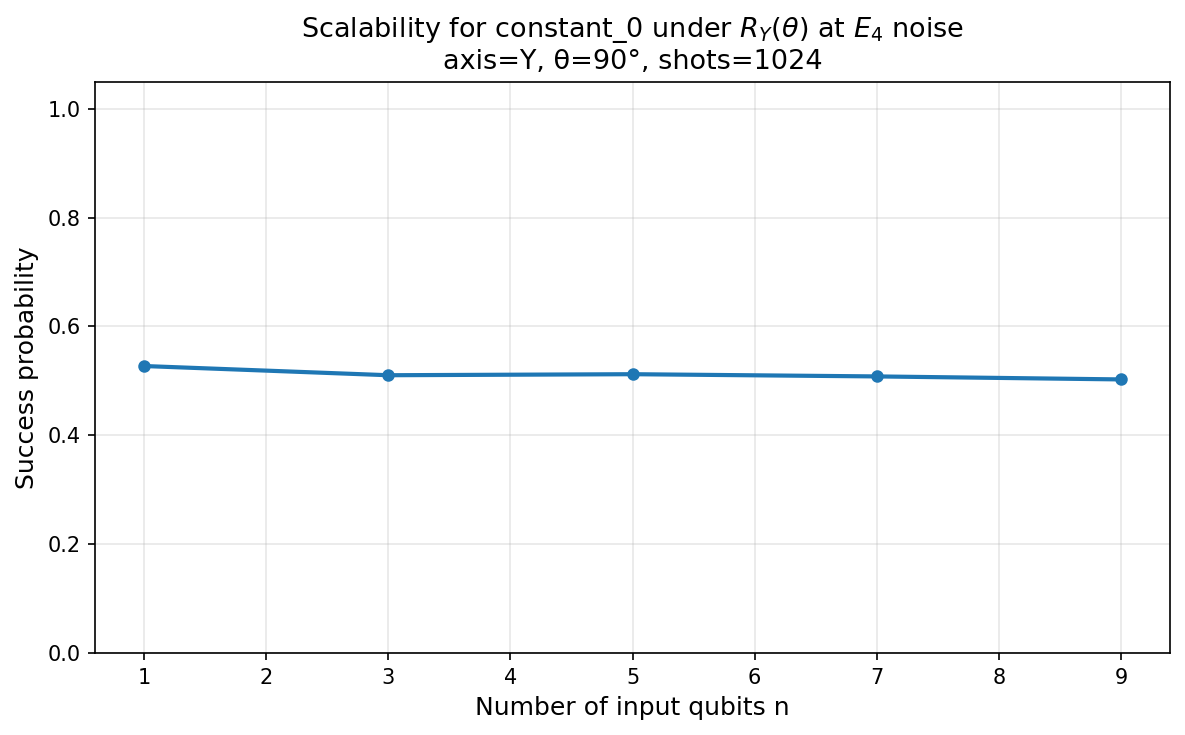

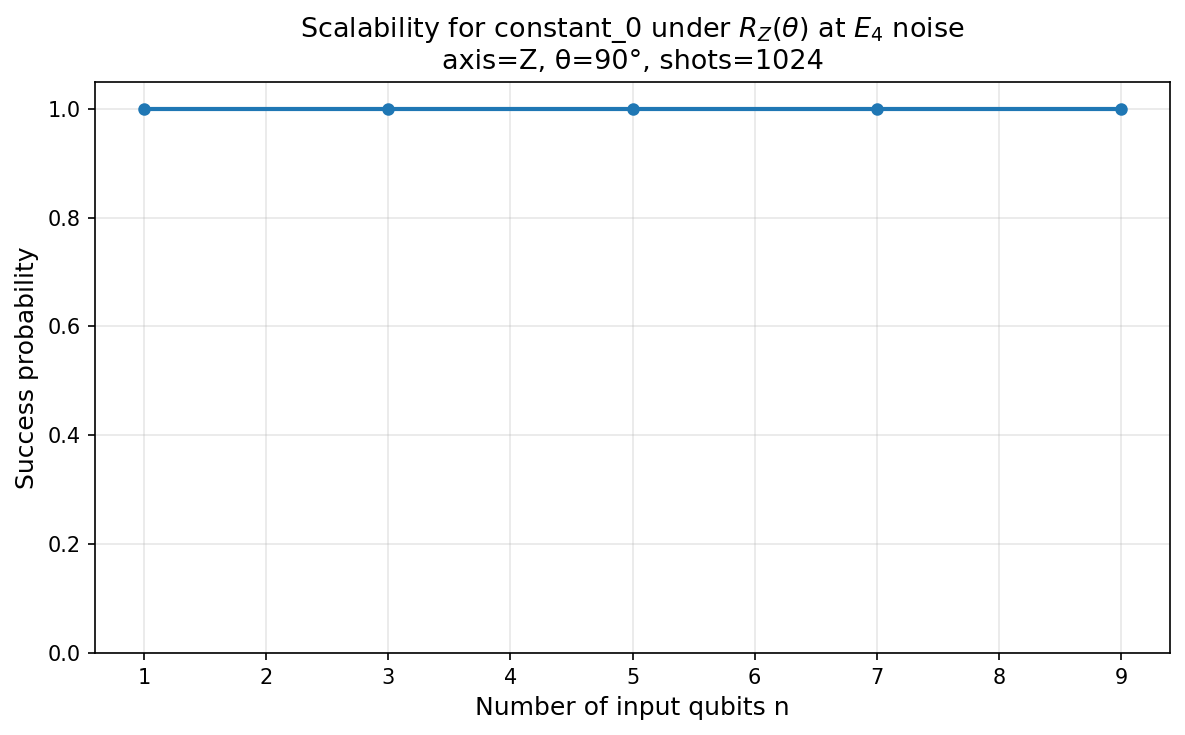

In [9]:
# Scalability example for the lab report
# theta = 90°, error position = E4 after final Hadamard

theta_choice = 90
error_choice = "E4_after_final_H"
shots = 1024

# Balanced function: compare X, Y, Z axes
for axis in ["X", "Y", "Z"]:
    qa.plotting.rotation_error_scalability(
        df,
        theta_choice,
        axis,
        error_choice,
        "balanced",
        shots
    )

# Constant function: compare X, Y, Z axes
for axis in ["X", "Y", "Z"]:
    qa.plotting.rotation_error_scalability(
        df,
        theta_choice,
        axis,
        error_choice,
        "constant_0",
        shots
    )